# Task 4 - Final hold-out benchmark and ultimate judgement

## From model development to one final decision

The development sequence now has a clear empirical direction. Reconstruction learned visual signal but weak semantic separation; Triplet corrected much of that gap; SupCon benefited from several positives; Multi-Similarity weighting did not improve the resulting ranking; and ArcFace's persistent class centres produced the strongest inner-validation result. The remaining question is no longer which mechanism to try next, but whether that ordering holds when every frozen model sees the same unseen queries and the same gallery.

This notebook therefore performs the only cross-model hold-out decision. Relevance is still defined by the train-fitted `articleType__gender` proxy, and no model, preprocessing statistic or hyperparameter is fitted here. Raw cosine ranking is reported separately from optional reranking so that representation quality is not confused with post-processing. The judgement combines ranking metrics, query coverage, embedding geometry, artifact footprint and qualitative errors rather than reducing the system to one score.


### Evaluation mechanism

![Final benchmark flow](figures/06_benchmark_flow.svg)

*Figure 1. Frozen models are compared through one controlled retrieval pipeline. Raw and reranked evidence remain separate so post-processing cannot be mistaken for representation quality [2], [3].*


## 1. Setup and reproducibility

All metric-learning models receive the deterministic letterbox, tensor conversion, and training-set RGB normalisation saved by notebook 00. The CAE receives unnormalised `[0, 1]` pixels to match its reconstruction training. The random seed fixes qualitative example selection and loader order; CUDA kernels may still not be bitwise deterministic.

All candidates use a 512-D L2-normalised embedding, so inner-product FAISS search is cosine ranking [2]. ArcFace's training-only class head is excluded at inference; Triplet, SupCon, MS, and ArcFace therefore deploy the same ResNet-18 encoder capacity.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image

from src.task4.config import (
    ARTIFACT_DIR,
    CONFIG_DIR,
    IMAGE_DIR,
    MODEL_DIR,
    SEED,
    SPLIT_DIR,
)
from src.task4.data import make_evaluation_loader
from src.task4.models import ConvolutionalAutoencoder, ResNet18Encoder
from src.task4.preprocessing import cae_transform, metric_eval_transform
from src.task4.retrieval import (
    extract_color_descriptors,
    extract_embeddings,
    k_reciprocal_rerank,
    retrieval_metrics,
    search_cosine,
)
from src.task4.training import DEVICE, set_seed

set_seed(SEED)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

MODEL_NAMES = ("cae", "triplet", "supcon", "multi_similarity", "arcface")
EVALUATION_TRANSFORMS = {
    "cae": cae_transform,
    "triplet": metric_eval_transform,
    "supcon": metric_eval_transform,
    "multi_similarity": metric_eval_transform,
    "arcface": metric_eval_transform,
}
PRIMARY_METRIC = "mAP@10"
RERANK_CONFIG = {
    "k1": 20,
    "k2": 6,
    "blend": 0.3,
    "candidate_depth": 100,
    "color_weight": 0.15,
}
BENCHMARK_DIR = ARTIFACT_DIR / "benchmark"
print(f"Device: {DEVICE}")

Device: cpu


## 2. Verify artifacts and construct the labelled test set

The preflight requires `best.pt`, `gallery_embeddings.npy`, and `gallery_ids.npy` for every candidate. This explicit contract supports the team's choice to distribute large artifacts through Drive instead of Git: missing files fail early rather than silently changing the comparison.

Test labels are recreated with the train-fitted encoder. Three encoder-unseen joint classes are excluded, then a further 29 queries whose class is absent from at least one saved gallery are removed so every model receives the same 3,745 queries. Coverage is therefore 3,745/3,777 = **99.15%**; the 32 excluded cases must be disclosed because the benchmark is closed-set rather than cold-start evaluation.


In [3]:
required_files = ("best.pt", "gallery_embeddings.npy", "gallery_ids.npy")
artifact_rows = []
for model_name in MODEL_NAMES:
    model_dir = MODEL_DIR / model_name
    missing = [name for name in required_files if not (model_dir / name).exists()]
    artifact_rows.append(
        {
            "Model": model_name,
            "Ready": not missing,
            "Missing artifacts": ", ".join(missing) if missing else "",
        }
    )

artifact_status = pd.DataFrame(artifact_rows)
display(artifact_status)

missing_models = artifact_status.loc[~artifact_status["Ready"], "Model"].tolist()
if missing_models:
    raise FileNotFoundError(
        "Final benchmark requires all five saved model bundles. Missing: "
        + ", ".join(missing_models)
    )

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Hold-out images are not available at {IMAGE_DIR}")

,Model,Ready,Missing artifacts
0,cae,True,
1,triplet,True,
2,supcon,True,
3,multi_similarity,True,
4,arcface,True,


### Artifact provenance before evaluation

All five checkpoint/gallery bundles and Optuna databases are present. Four supervised models also include history CSVs and learning curves; CAE does not.

The re-uploaded CAE gallery contains **30,422 IDs**, while the four supervised galleries contain **30,389**. Their intersection is 30,389 IDs, leaving 33 CAE-only entries. The next section now aligns every model to that intersection before a fresh fair comparison. Consequently, the rendered hold-out tables retained later in this notebook are labelled as a **previous saved execution** until the image path is restored and those evaluation cells are rerun.


In [4]:
with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    encoding="utf-8"
) as file:
    label_encoder = json.load(file)
label_to_index = label_encoder["label_to_index"]
classes = np.asarray(label_encoder["classes"], dtype=object)
LABEL_COLUMN = label_encoder["label_column"]
LABEL_ID_COLUMN = label_encoder["label_id_column"]
separator = label_encoder["separator"]

outer_train_df = pd.read_csv(SPLIT_DIR / "train.csv")
outer_train_df[LABEL_COLUMN] = (
    outer_train_df["articleType"].str.strip()
    + separator
    + outer_train_df["gender"].str.strip()
)
outer_train_df[LABEL_ID_COLUMN] = outer_train_df[LABEL_COLUMN].map(label_to_index)

test_df = pd.read_csv(SPLIT_DIR / "test.csv")
test_df[LABEL_COLUMN] = (
    test_df["articleType"].str.strip() + separator + test_df["gender"].str.strip()
)
test_df[LABEL_ID_COLUMN] = test_df[LABEL_COLUMN].map(label_to_index)


In [5]:
test_rows_before_filtering = len(test_df)
unseen_class_mask = test_df[LABEL_ID_COLUMN].isna()
removed_unseen_rows = int(unseen_class_mask.sum())
test_df = test_df.loc[~unseen_class_mask].copy()
test_df[LABEL_ID_COLUMN] = test_df[LABEL_ID_COLUMN].astype("int64")

print(f"Hold-out test rows before filtering: {test_rows_before_filtering:,}")
print(f"Rows removed for encoder-unseen classes: {removed_unseen_rows:,}")
print(f"Seen-class test rows retained: {len(test_df):,}")


Hold-out test rows before filtering: 3,777
Rows removed for encoder-unseen classes: 3
Seen-class test rows retained: 3,774


## 3. Model loading helpers

Each checkpoint is restored in evaluation mode. ArcFace's class-centre head is training-only and removed before loading the common encoder. The CAE currently loads its decoder as well because its forward method returns both reconstruction and embedding; an encoder-only deployment would reduce CAE latency and memory without changing its retrieval vector.


In [ ]:
def build_model(model_name: str):
    return (
        ConvolutionalAutoencoder(ResNet18Encoder())
        if model_name == "cae"
        else ResNet18Encoder()
    )


def load_model(model_name: str):
    checkpoint = torch.load(
        MODEL_DIR / model_name / "best.pt", map_location=DEVICE, weights_only=False
    )
    state_dict = checkpoint["model_state_dict"]
    if model_name == "arcface":
        state_dict = {
            key: value
            for key, value in state_dict.items()
            if not key.startswith("arcface_loss.")
        }

    model = build_model(model_name)
    model.load_state_dict(state_dict)
    return model.to(DEVICE).eval()

## 4. Extract test embeddings and apply one fixed retrieval protocol

The saved galleries are first inspected in their original form, then aligned to the **intersection of gallery IDs** in sorted order. This prevents the current CAE bundle from receiving 33 extra candidates. Outer hold-out images are queries; FAISS performs exact inner-product search on normalised vectors [2].

The reranker uses fixed settings (`k1=20`, `k2=6`, 0.3 original/Jaccard blend, 100 candidates, HSV colour weight 0.15) for every model. It is inspired by—not an exact reproduction of—Zhong *et al.* [3].


In [8]:
gallery_label_by_id = outer_train_df.set_index("id")[LABEL_ID_COLUMN]
galleries = {}

for model_name in MODEL_NAMES:
    model_dir = MODEL_DIR / model_name
    embeddings = np.load(model_dir / "gallery_embeddings.npy").astype("float32")
    ids = np.load(model_dir / "gallery_ids.npy").astype("int64")
    if len(embeddings) != len(ids):
        raise ValueError(
            f"{model_name}: gallery embeddings and IDs must have equal length"
        )

    labels = gallery_label_by_id.reindex(ids)
    if labels.isna().any():
        raise ValueError(f"{model_name}: a saved gallery ID is absent from train.csv")
    galleries[model_name] = {
        "embeddings": embeddings,
        "ids": ids,
        "labels": labels.to_numpy(dtype="int64"),
    }

common_labels = set.intersection(
    *(set(galleries[name]["labels"]) for name in MODEL_NAMES)
)
evaluation_df = test_df[test_df[LABEL_ID_COLUMN].isin(common_labels)].copy()
if evaluation_df.empty:
    raise ValueError("No test query class appears in every model gallery")

print(f"Scored hold-out queries: {len(evaluation_df):,}")
print(f"Excluded encoder-unseen queries: {removed_unseen_rows:,}")
print(
    f"Excluded queries absent from at least one gallery: {len(test_df) - len(evaluation_df):,}"
)

Scored hold-out queries: 3,745
Excluded encoder-unseen queries: 3
Excluded queries absent from at least one gallery: 29


### 4.1 Artifact-only embedding-geometry diagnostic

To add evidence beyond top-K scores, the next cell samples 50,000 same-class and 50,000 different-class pairs from each saved gallery with seed 42. The **mean gap** measures average separation. The stricter **robust gap** is $P10(same)-P90(different)$: positive values indicate separation even between the lower tail of relevant pairs and upper tail of irrelevant pairs.

This is a diagnostic rather than a standard leaderboard metric; it does not use hold-out images and does not replace mAP.


Model,Gallery items,Same-class mean,Different-class mean,Mean gap,Same P10,Different P90,Robust gap
CAE,30422,0.9575,0.9288,0.0287,0.9235,0.9642,-0.0407
Triplet,30389,0.9278,0.4764,0.4513,0.8668,0.6698,0.1969
SupCon,30389,0.9808,0.3220,0.6587,0.9573,0.6705,0.2868
Multi-Similarity,30389,0.9724,0.3284,0.6441,0.9275,0.5342,0.3932
ArcFace,30389,0.8993,0.2756,0.6237,0.7773,0.3341,0.4432


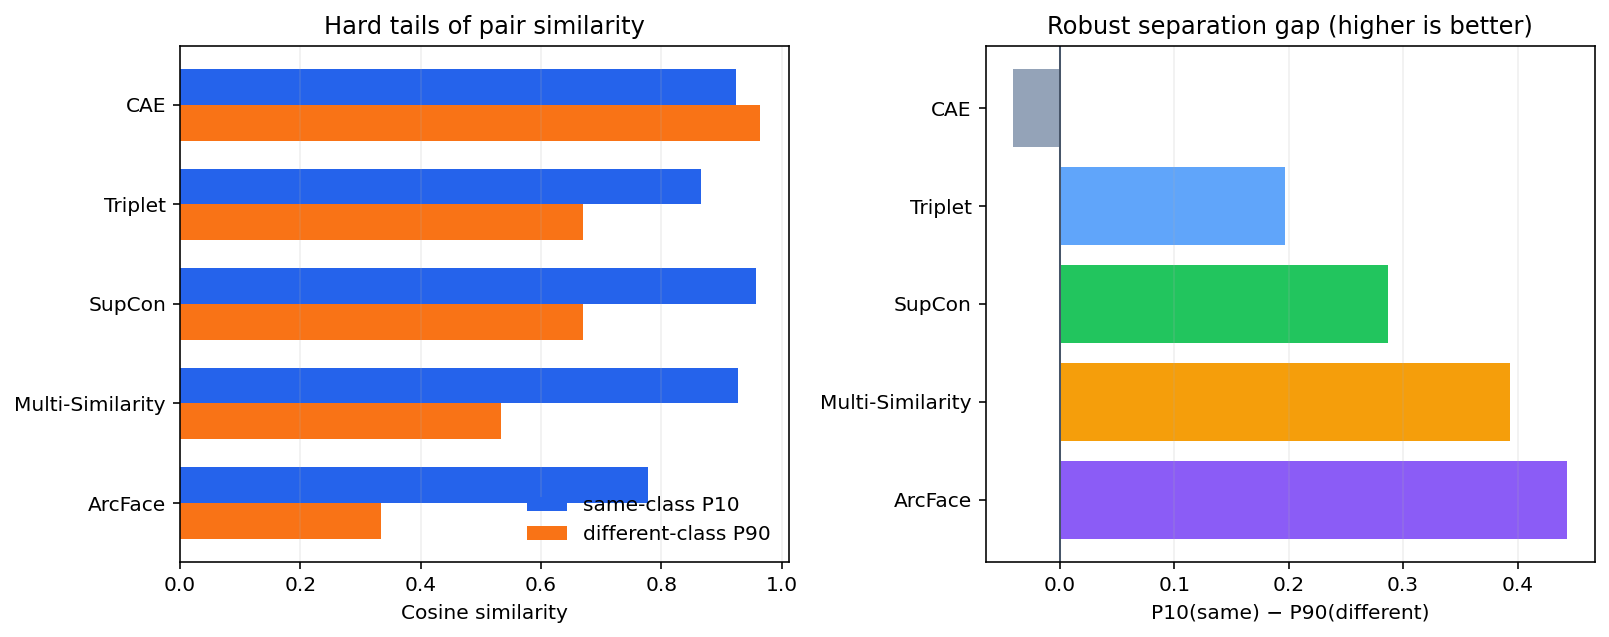

In [33]:
def sample_embedding_geometry(gallery, n_pairs=50_000, seed=SEED):
    embeddings = gallery["embeddings"].astype("float32")
    embeddings /= np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12)
    labels = gallery["labels"]
    groups = {}
    for index, label in enumerate(labels):
        groups.setdefault(int(label), []).append(index)
    groups = {label: np.asarray(indices) for label, indices in groups.items()}
    eligible = np.asarray([i for i, label in enumerate(labels) if len(groups[int(label)]) > 1])
    rng = np.random.default_rng(seed)
    anchors = rng.choice(eligible, size=n_pairs, replace=True)
    positives = np.empty(n_pairs, dtype="int64")
    for row, anchor in enumerate(anchors):
        candidates = groups[int(labels[anchor])]
        positive = anchor
        while positive == anchor:
            positive = rng.choice(candidates)
        positives[row] = positive
    negatives = rng.integers(0, len(labels), size=n_pairs)
    invalid = labels[negatives] == labels[anchors]
    while invalid.any():
        negatives[invalid] = rng.integers(0, len(labels), size=int(invalid.sum()))
        invalid = labels[negatives] == labels[anchors]
    same = np.sum(embeddings[anchors] * embeddings[positives], axis=1)
    different = np.sum(embeddings[anchors] * embeddings[negatives], axis=1)
    same_p10, different_p90 = np.quantile(same, 0.10), np.quantile(different, 0.90)
    return {
        "Gallery items": len(labels),
        "Same-class mean": same.mean(),
        "Different-class mean": different.mean(),
        "Mean gap": same.mean() - different.mean(),
        "Same P10": same_p10,
        "Different P90": different_p90,
        "Robust gap": same_p10 - different_p90,
    }

geometry_table = pd.DataFrame(
    [{"Model": name, **sample_embedding_geometry(galleries[name])} for name in MODEL_NAMES]
)
display(geometry_table.style.format(precision=4).set_caption("Saved-gallery geometry (50,000 pairs per group)"))

y = np.arange(len(geometry_table))
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))
axes[0].barh(y - 0.18, geometry_table["Same P10"], height=0.36, label="same-class P10")
axes[0].barh(y + 0.18, geometry_table["Different P90"], height=0.36, label="different-class P90")
axes[0].set_yticks(y, geometry_table["Model"])
axes[0].invert_yaxis()
axes[0].set_xlabel("Cosine similarity")
axes[0].set_title("Hard tails of pair similarity")
axes[0].legend(frameon=False)
axes[1].barh(y, geometry_table["Robust gap"])
axes[1].set_yticks(y, geometry_table["Model"])
axes[1].invert_yaxis()
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("P10(same) − P90(different)")
axes[1].set_title("Robust separation gap")
plt.tight_layout()
plt.show()


### Geometry interpretation

CAE has a negative robust gap, confirming that its same- and different-class neighbourhoods overlap heavily. SupCon has the largest average gap, but ArcFace has the largest robust gap (**0.4432**) and the narrowest different-class spread. This explains why one global mean cannot predict top-K quality: ArcFace controls the hard negative tail more consistently.

The CAE row also exposes the current 30,422-versus-30,389 gallery mismatch. The evaluation code subsequently intersects IDs for the fair hold-out rerun.


In [ ]:
common_gallery_ids = sorted(
    set.intersection(*(set(galleries[name]["ids"].tolist()) for name in MODEL_NAMES))
)
if not common_gallery_ids:
    raise ValueError("No gallery ID is shared by all model artifacts")

for model_name in MODEL_NAMES:
    gallery = galleries[model_name]
    position_by_id = {int(image_id): i for i, image_id in enumerate(gallery["ids"])}
    positions = np.asarray([position_by_id[image_id] for image_id in common_gallery_ids])
    galleries[model_name] = {
        "embeddings": gallery["embeddings"][positions],
        "ids": np.asarray(common_gallery_ids, dtype="int64"),
        "labels": gallery["labels"][positions],
    }

reference_gallery_ids = galleries[MODEL_NAMES[0]]["ids"]
print(f"Common gallery IDs used by every model: {len(reference_gallery_ids):,}")
gallery_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in reference_gallery_ids
)

evaluation_ids = evaluation_df["id"].to_numpy(dtype="int64")
query_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in evaluation_ids
)


In [ ]:
model_outputs = {}
raw_summary_rows = []
reranked_summary_rows = []
for model_name in MODEL_NAMES:
    gallery = galleries[model_name]
    model = load_model(model_name)
    query_loader = make_evaluation_loader(
        evaluation_df, EVALUATION_TRANSFORMS[model_name], IMAGE_DIR
    )
    query_embeddings, query_ids, query_labels = extract_embeddings(model, query_loader)
    if not np.array_equal(query_ids, evaluation_ids):
        raise ValueError(
            f"{model_name}: query order does not match the colour descriptors"
        )

    _, raw_ranked_indices, index = search_cosine(
        query_embeddings, gallery["embeddings"], maximum_k=10
    )
    reranked_indices = k_reciprocal_rerank(
        query_embeddings,
        gallery["embeddings"],
        index,
        query_color_descriptors=query_color_descriptors,
        gallery_color_descriptors=gallery_color_descriptors,
        **RERANK_CONFIG,
    )

    raw_summary_rows.append(
        {
            "Model": model_name,
            **retrieval_metrics(raw_ranked_indices, query_labels, gallery["labels"]),
        }
    )
    reranked_summary_rows.append(
        {
            "Model": model_name,
            **retrieval_metrics(reranked_indices, query_labels, gallery["labels"]),
        }
    )
    model_outputs[model_name] = {
        "gallery_ids": gallery["ids"],
        "gallery_labels": gallery["labels"],
        "query_ids": query_ids,
        "query_labels": query_labels,
        "ranked_indices": reranked_indices,
    }

## 5. Why the benchmark needs more than “accuracy”

Classification accuracy would answer whether one class label was predicted correctly. That is not the product behaviour in Task 4: the system returns an ordered list containing many potentially relevant products. Precision@1 therefore measures whether the first recommendation is relevant, while Precision@5 and Precision@10 describe the purity of the list as the user browses further.

Recall@K asks a different question: how much of the relevant gallery has been recovered within the first K positions. Its values are naturally small when a query may have hundreds of relevant products but the interface displays at most ten. mAP@10 is used as the primary selection metric because it rewards both relevance and early ordering rather than treating every returned position equally [1].

The numerical ranking is complemented by coverage, which discloses queries that cannot be scored fairly in the closed-set gallery; rerank delta, which reveals whether post-processing helps or masks a weak embedding; and the artifact-only geometry diagnostic, which compares same- and different-class cosine distributions. Checkpoint size, missing histories and qualitative retrieval examples provide operational and error-analysis evidence that no single accuracy-like value can capture. All ranking metrics are macro-averaged over queries so common classes do not receive extra weight simply because they contain more queries.


In [15]:
metric_columns = [
    "Precision@1",
    "Precision@5",
    "Precision@10",
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "mAP@10",
]
raw_comparison_table = (
    pd.DataFrame(raw_summary_rows)
    .set_index("Model")
    .loc[:, metric_columns]
    .sort_values(PRIMARY_METRIC, ascending=False)
)
reranked_comparison_table = (
    pd.DataFrame(reranked_summary_rows)
    .set_index("Model")
    .loc[:, metric_columns]
    .sort_values(PRIMARY_METRIC, ascending=False)
)
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
raw_comparison_table.to_csv(BENCHMARK_DIR / "holdout_raw_cosine_comparison.csv")
reranked_comparison_table.to_csv(
    BENCHMARK_DIR / "holdout_reranked_colour_comparison.csv"
)


In [19]:
caption_style = [
    {
        "selector": "caption",
        "props": [
            ("caption-side", "top"),
            ("font-weight", "700"),
            ("font-size", "1.1em"),
            ("padding-bottom", "0.4em"),
        ],
    }
]

display(
    raw_comparison_table.style
    .set_caption("Raw cosine retrieval")
    .format("{:.4f}")
    .highlight_max(
        axis=0,
        props="font-weight: 700; text-decoration: underline;",
    )
    .set_table_styles(caption_style)
)

display(
    reranked_comparison_table.style
    .set_caption("K-reciprocal reranking + HSV colour histogram")
    .format("{:.4f}")
    .highlight_max(
        axis=0,
        props="font-weight: 700; text-decoration: underline;",
    )
    .set_table_styles(caption_style)
)

winner = reranked_comparison_table.index[0]
print(f"Leading reranked model by {PRIMARY_METRIC}: {winner}")


,Precision@1,Precision@5,Precision@10,Recall@1,Recall@5,Recall@10,mAP@10
Model,,,,,,,
arcface,0.8083,0.8081,0.8053,0.0036,0.0178,0.0340,0.7880
supcon,0.7893,0.7837,0.7817,0.0035,0.0176,0.0343,0.7420
multi_similarity,0.7645,0.7536,0.7473,0.0035,0.0175,0.0332,0.6933
triplet,0.7821,0.7551,0.7442,0.0035,0.0167,0.0313,0.6897
cae,0.6977,0.6236,0.5842,0.0026,0.0101,0.0174,0.5067


,Precision@1,Precision@5,Precision@10,Recall@1,Recall@5,Recall@10,mAP@10
Model,,,,,,,
arcface,0.8067,0.8068,0.8051,0.0036,0.0179,0.0343,0.7886
supcon,0.7826,0.7828,0.7796,0.0036,0.0172,0.0335,0.7426
multi_similarity,0.7562,0.7522,0.7471,0.0035,0.0172,0.0330,0.6963
triplet,0.7535,0.7501,0.7438,0.0033,0.0165,0.0318,0.6904
cae,0.5987,0.5927,0.5782,0.0017,0.0087,0.0163,0.4992


Leading reranked model by mAP@10: arcface


### Interpretation of the previous saved hold-out execution

The saved tables show ArcFace first on every reranked metric and SupCon second. MS and Triplet are close; a single split cannot establish that their small gap is stable. Reranking changes supervised mAP@10 by at most 0.0030 and harms CAE, so it is an optional refinement rather than the source of the ordering.

Because the re-uploaded CAE gallery now contains 33 extra IDs, these displayed values are retained as historical evidence, not claimed as a fresh execution of the current artifact bundle. The alignment code above must be rerun before final submission.


## 6. Visual comparison
The chart uses reranked mAP@10 because this is the declared pipeline-selection metric. The numeric labels prevent visual exaggeration from the truncated axis. Pair it with the raw table: a model should not receive credit for representation quality that actually comes from post-processing.


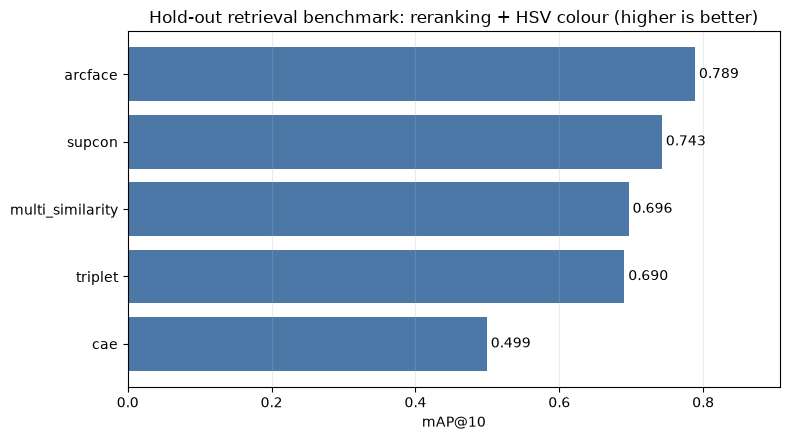

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_values = reranked_comparison_table[PRIMARY_METRIC].sort_values()
ax.barh(plot_values.index, plot_values.values, color="#4c78a8")
ax.set_xlabel("mAP@10")
ax.set_title("Hold-out retrieval benchmark: reranking + HSV colour (higher is better)")
ax.set_xlim(0, min(1.0, max(0.05, plot_values.max() * 1.15)))
ax.grid(axis="x", alpha=0.25)
for y, value in enumerate(plot_values.values):
    ax.text(value, y, f" {value:.3f}", va="center")
fig.tight_layout()
fig.savefig(
    BENCHMARK_DIR / "holdout_reranked_colour_map_at_10_comparison.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## 7. Qualitative retrieval audit
Two seeded hold-out queries and their top-three results provide a readable error audit. A check mark means the proxy label matches, not that a human necessarily judges the items visually interchangeable. Discuss colour, silhouette, pattern, framing, and any proxy-label mismatch visible in each row; do not use two examples as quantitative evidence.


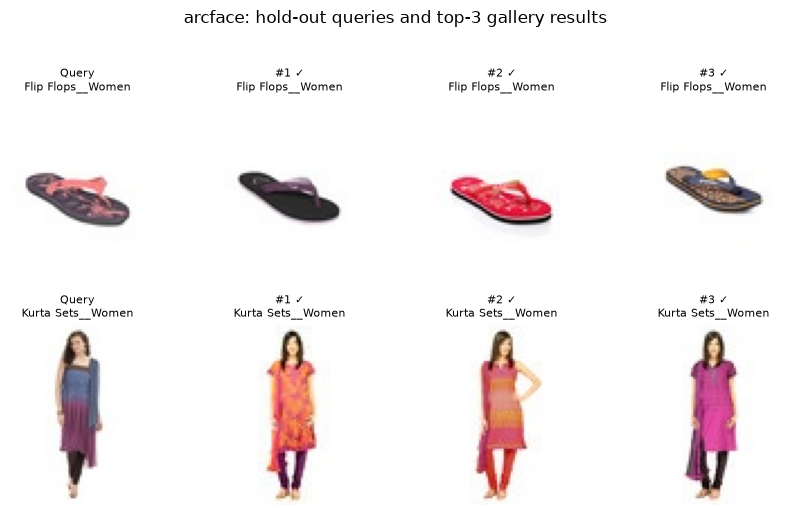

In [32]:
def show_retrieval_examples(model_name=winner, n_queries=2, k=3, seed=SEED):
    output = model_outputs[model_name]
    rng = np.random.default_rng(seed)
    chosen = rng.choice(
        len(output["query_ids"]),
        size=min(n_queries, len(output["query_ids"])),
        replace=False,
    )
    fig, axes = plt.subplots(
        len(chosen), k + 1, figsize=(2.2 * (k + 1), 2.5 * len(chosen))
    )
    axes = np.atleast_2d(axes)

    for row, query_index in enumerate(chosen):
        query_id = output["query_ids"][query_index]
        query_label = classes[output["query_labels"][query_index]]
        gallery_indices = output["ranked_indices"][query_index, :k]
        ids = [query_id, *output["gallery_ids"][gallery_indices]]
        labels = [query_label, *classes[output["gallery_labels"][gallery_indices]]]
        for column, (item_id, item_label) in enumerate(zip(ids, labels)):
            with Image.open(IMAGE_DIR / f"{int(item_id)}.jpg") as image:
                axes[row, column].imshow(image.convert("RGB"))
            axes[row, column].axis("off")
            if column == 0:
                axes[row, column].set_title(f"Query\n{item_label}", fontsize=8)
            else:
                is_relevant = item_label == query_label
                axes[row, column].set_title(
                    f"#{column} {'✓' if is_relevant else '✗'}\n{item_label}", fontsize=8
                )
    fig.suptitle(f"{model_name}: hold-out queries and top-{k} gallery results", y=1.02)
    fig.tight_layout()
    plt.show()


show_retrieval_examples(model_name=winner, n_queries=2, k=3, seed=42)

## 8. Ultimate judgement and limitations

The previous saved hold-out execution gives the following reranked comparison.

| Model | P@1 | P@5 | P@10 | R@10 | mAP@10 | Rerank Δ mAP |
|---|---:|---:|---:|---:|---:|---:|
| ArcFace | **0.8067** | **0.8068** | **0.8051** | **0.0343** | **0.7886** | +0.0006 |
| SupCon | 0.7826 | 0.7828 | 0.7796 | 0.0335 | 0.7426 | +0.0006 |
| Multi-Similarity | 0.7562 | 0.7522 | 0.7471 | 0.0330 | 0.6963 | +0.0030 |
| Triplet | 0.7535 | 0.7501 | 0.7438 | 0.0318 | 0.6904 | +0.0007 |
| CAE | 0.5987 | 0.5927 | 0.5782 | 0.0163 | 0.4992 | −0.0075 |

The progression observed during development remains visible. Semantic supervision creates the large jump from CAE to Triplet, learning from several positives moves SupCon further ahead, and similarity-dependent weighting does not improve on that representation. ArcFace then provides the cleanest visible result list and the highest mAP@10. Its reranking gain is only 0.0006, so the decision is driven by the learned embedding rather than the colour-based second stage. The artifact geometry supports the same interpretation: ArcFace has the strongest robust separation of hard same- and different-class pairs, even though SupCon has the larger mean gap.

On the available evidence, ArcFace is the recommended Task 4 model and SupCon is the strongest fallback. This is not presented as a universal result. The experiment uses one seed, one split and a coarse semantic relevance proxy; the earlier saved evaluation covers 3,745 of 3,777 queries; CAE history is missing; and ArcFace tuning contains the class-centre caveat described in notebook 05.

There is also a current artifact mismatch that prevents the saved hold-out table from being claimed as a fresh reproduction. CAE contains 30,422 gallery IDs, while the supervised artifacts contain 30,389. The evaluation code now aligns all models to the 30,389-ID intersection, but the expected input image path is unavailable in this workspace, so those inference cells have not been rerun. The table above is therefore retained as previous evidence, and the aligned evaluation must be refreshed before final submission.

For deployment provenance, CAE uses a 55.95 MB checkpoint and lacks its history CSV. Triplet, SupCon and Multi-Similarity each use approximately 44.78 MB checkpoints, while ArcFace uses 45.29 MB; the ArcFace training head is removed at inference, leaving the same deployed ResNet-18 encoder capacity as the other supervised candidates.


## References

[1] C. D. Manning, P. Raghavan, and H. Schütze, *Introduction to Information Retrieval*. Cambridge, U.K.: Cambridge Univ. Press, 2008, ch. 8. [Online]. Available: https://nlp.stanford.edu/IR-book/

[2] J. Johnson, M. Douze, and H. Jégou, "Billion-scale similarity search with GPUs," *IEEE Trans. Big Data*, vol. 7, no. 3, pp. 535-547, 2021, doi: [10.1109/TBDATA.2019.2921572](https://doi.org/10.1109/TBDATA.2019.2921572).

[3] Z. Zhong, L. Zheng, D. Cao, and S. Li, "Re-ranking person re-identification with k-reciprocal encoding," in *Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2017, pp. 1318-1327. [Online]. Available: https://openaccess.thecvf.com/content_cvpr_2017/html/Zhong_Re-Ranking_Person_Re-Identification_CVPR_2017_paper.html

[4] J. Deng, J. Guo, N. Xue, and S. Zafeiriou, "ArcFace: Additive angular margin loss for deep face recognition," in *Proc. IEEE/CVF Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2019, pp. 4690-4699. [Online]. Available: https://openaccess.thecvf.com/content_CVPR_2019/html/Deng_ArcFace_Additive_Angular_Margin_Loss_for_Deep_Face_Recognition_CVPR_2019_paper.html

[5] P. Khosla *et al.*, "Supervised contrastive learning," in *Advances in Neural Information Processing Systems*, vol. 33, 2020, pp. 18661-18673. [Online]. Available: https://proceedings.neurips.cc/paper/2020/hash/d89a66c7c80a29b1bdbab0f2a1a94af8-Abstract.html
